# ``` Turning Evaluation Evidence into Action```


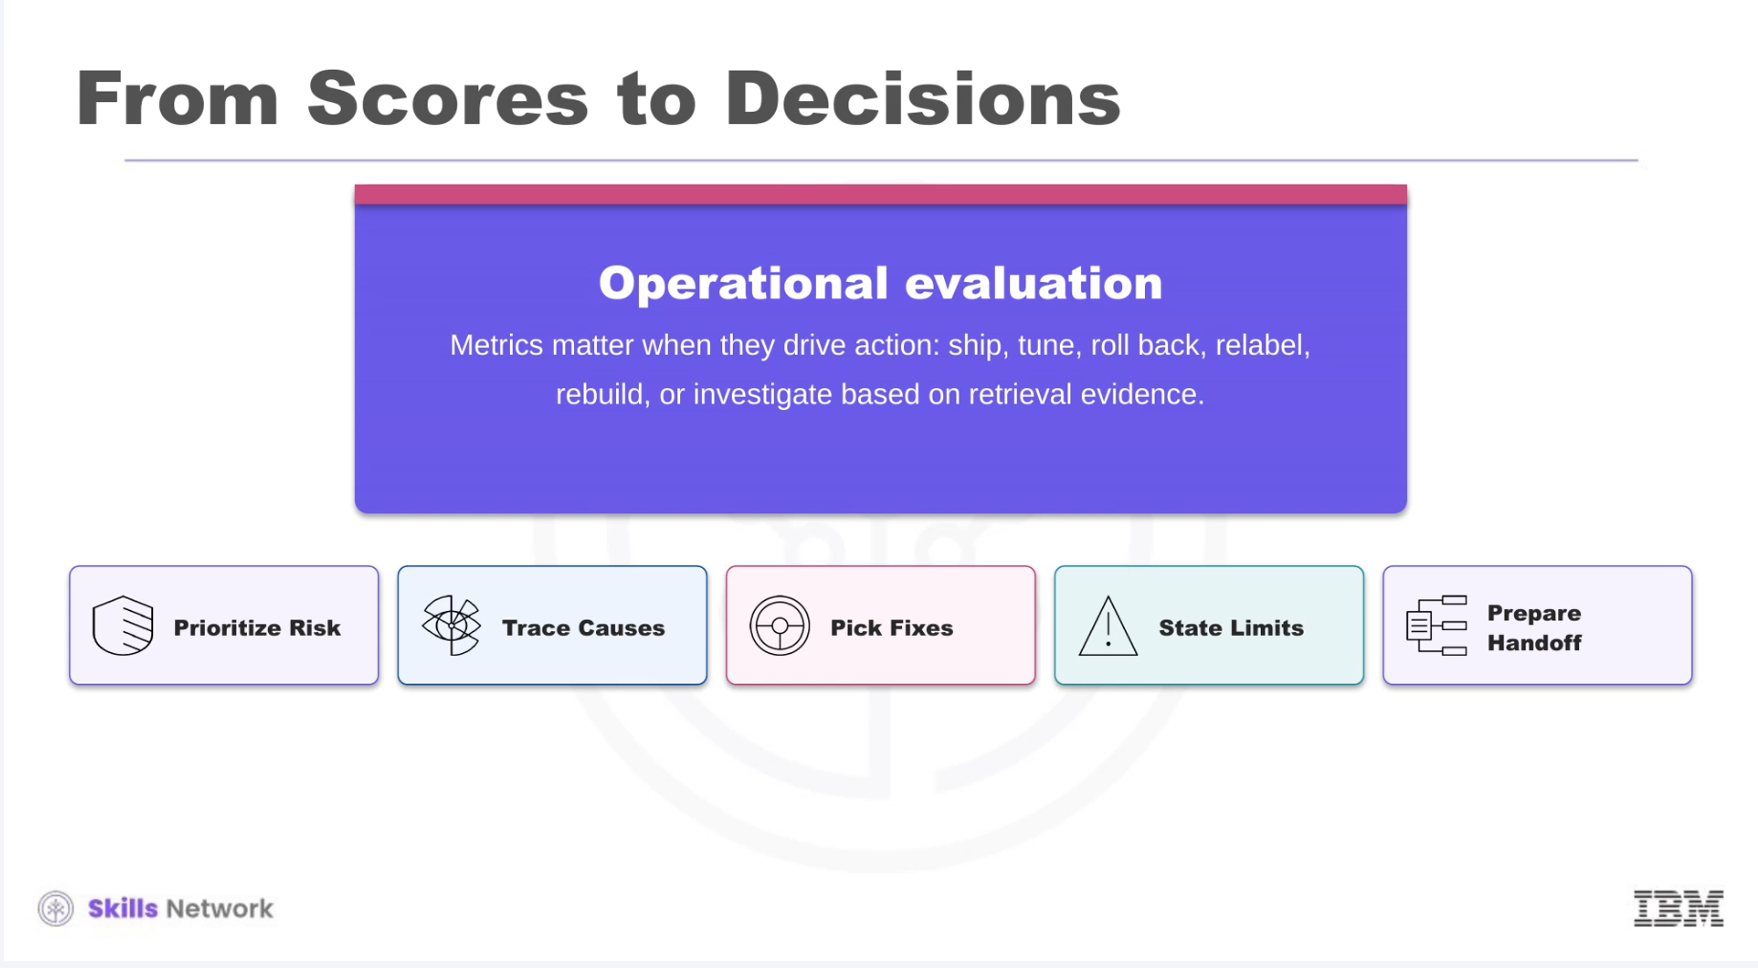
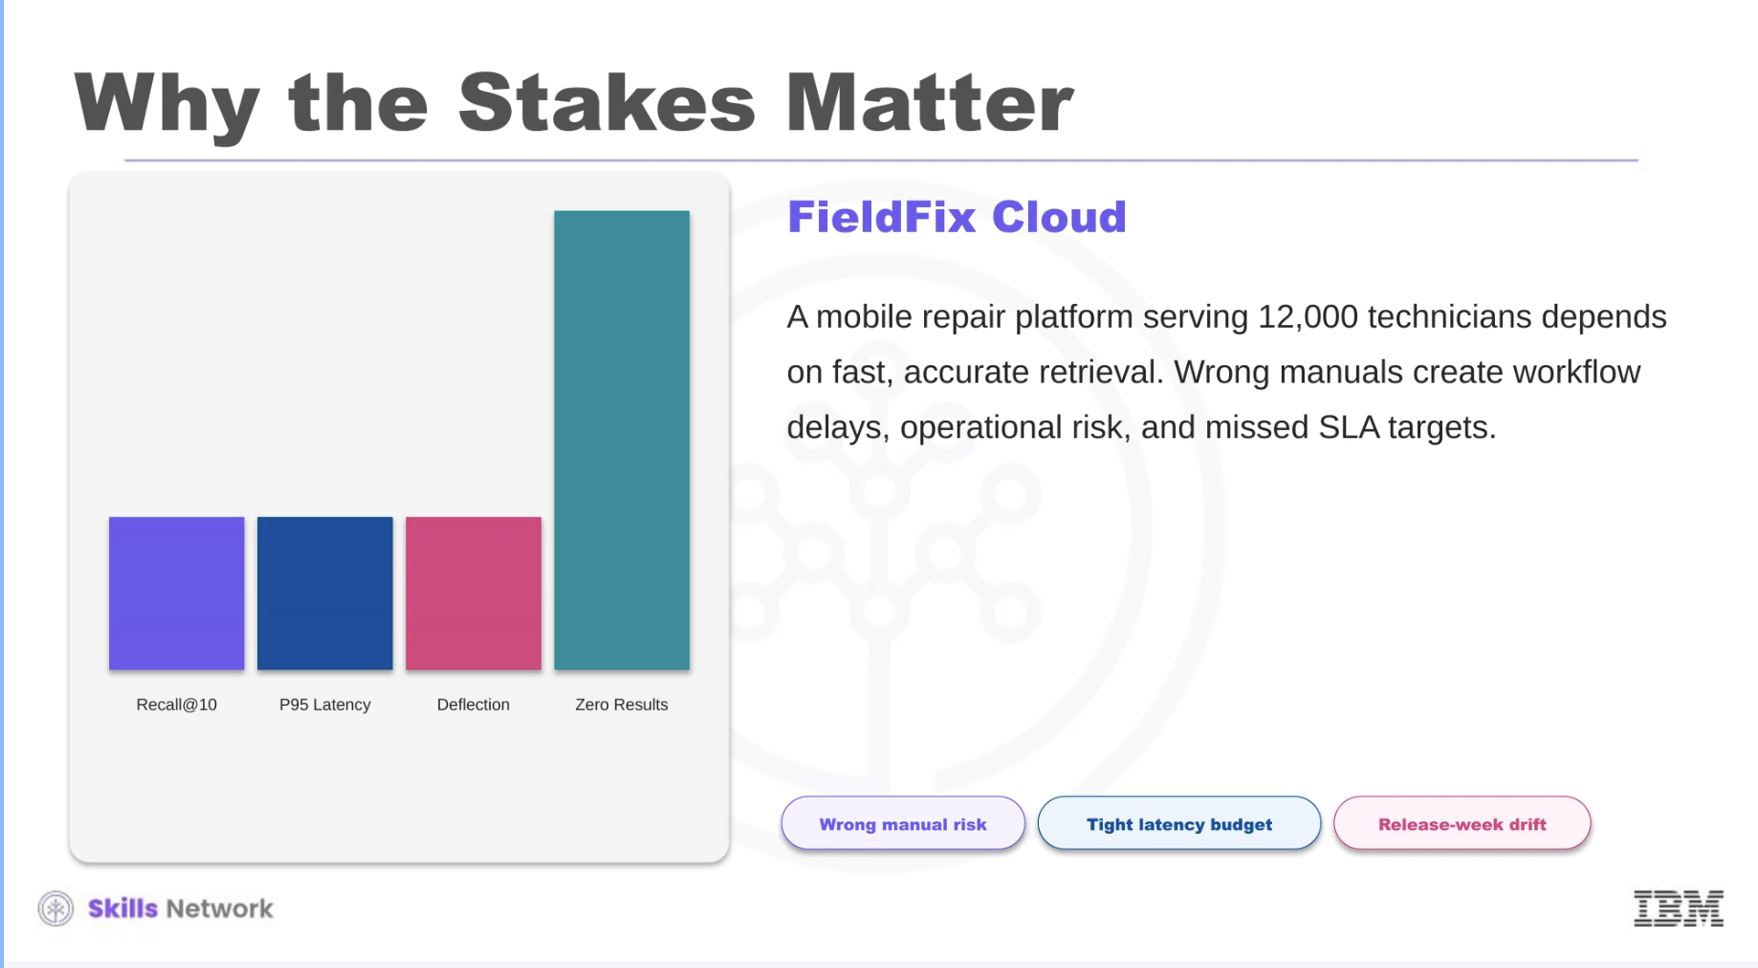
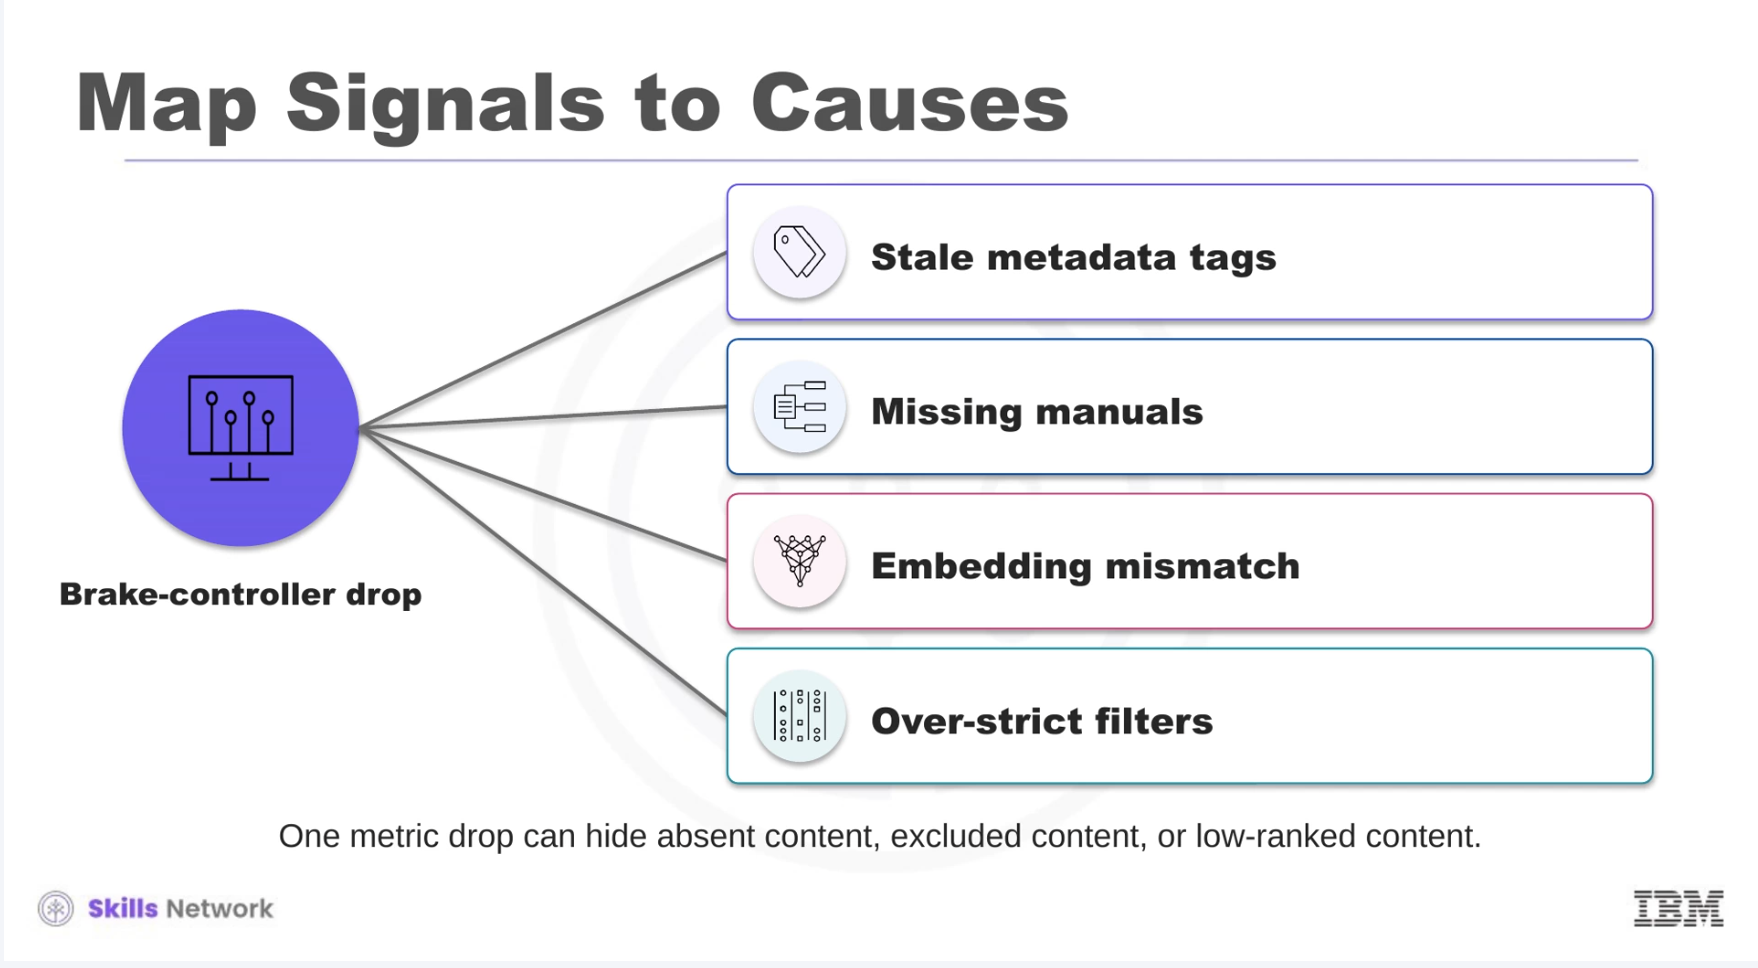
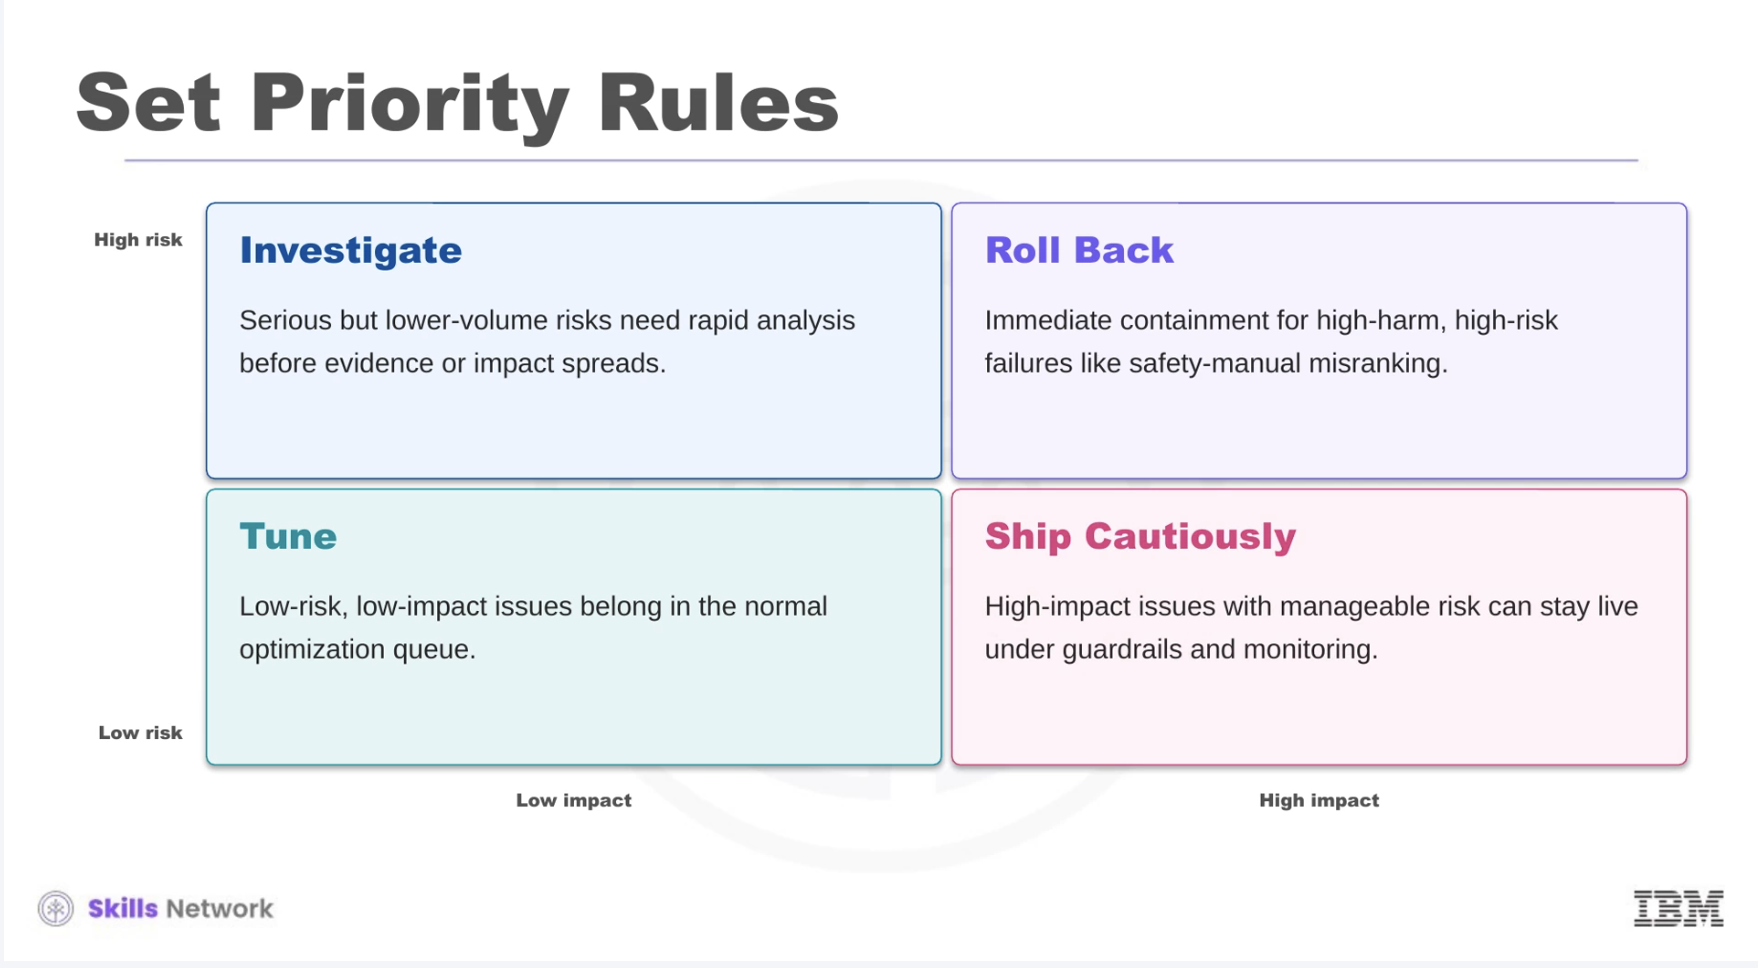
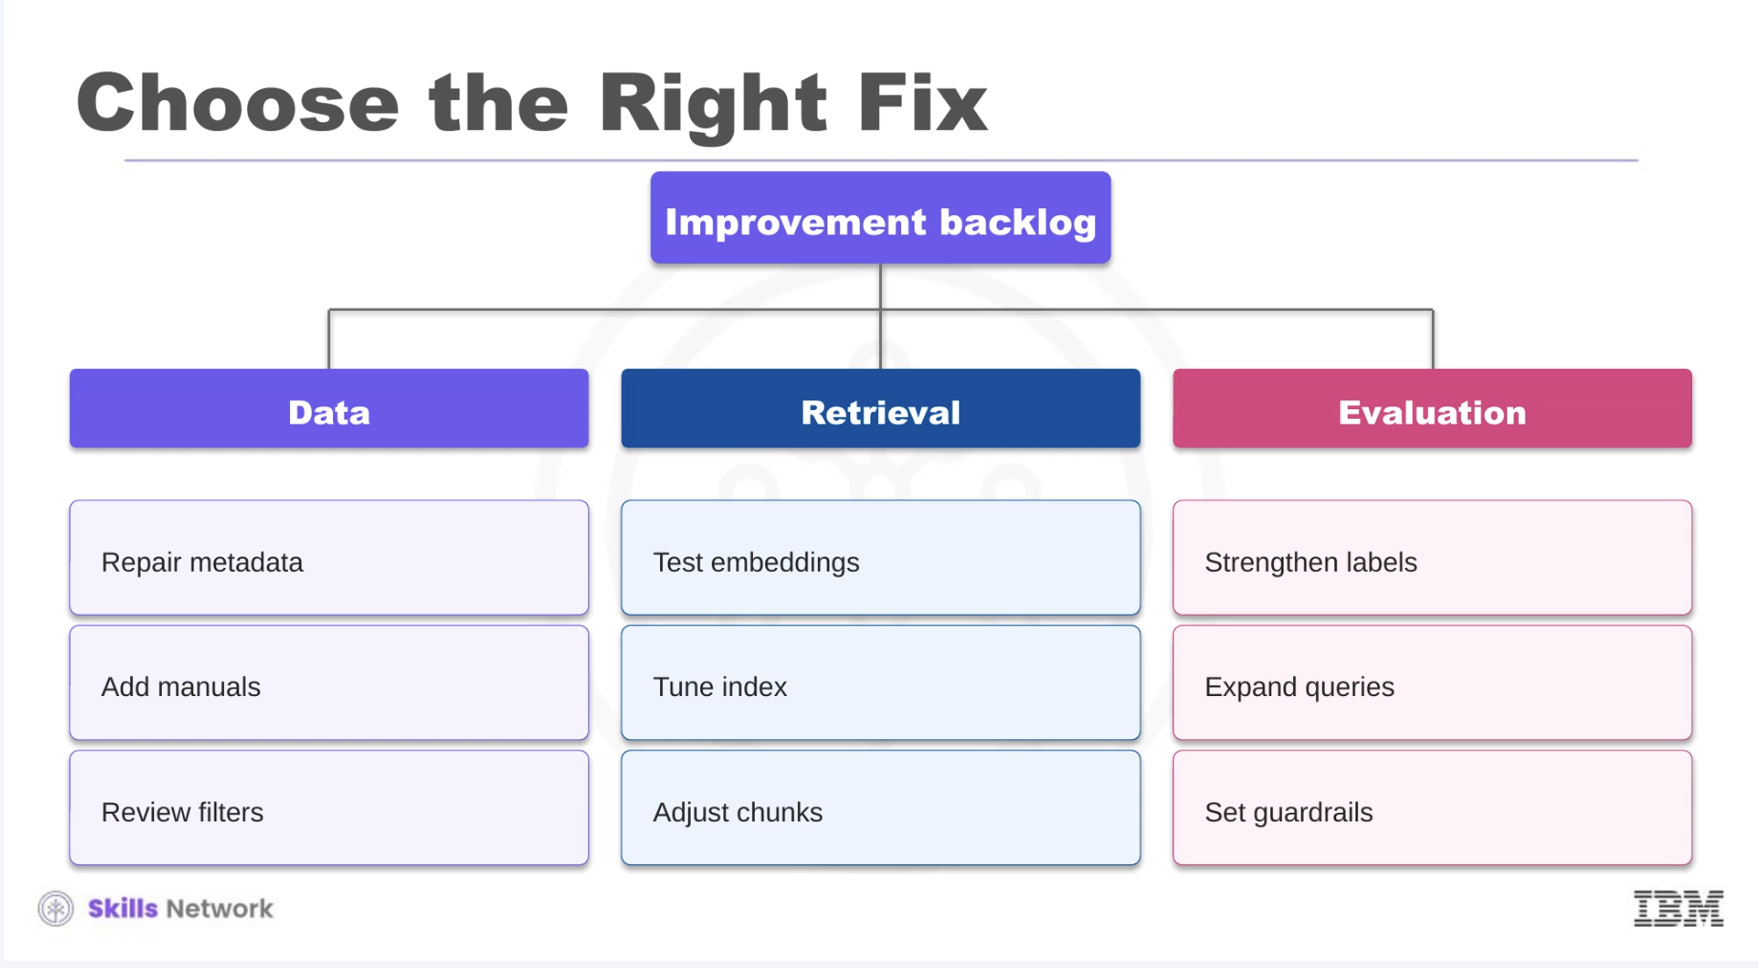
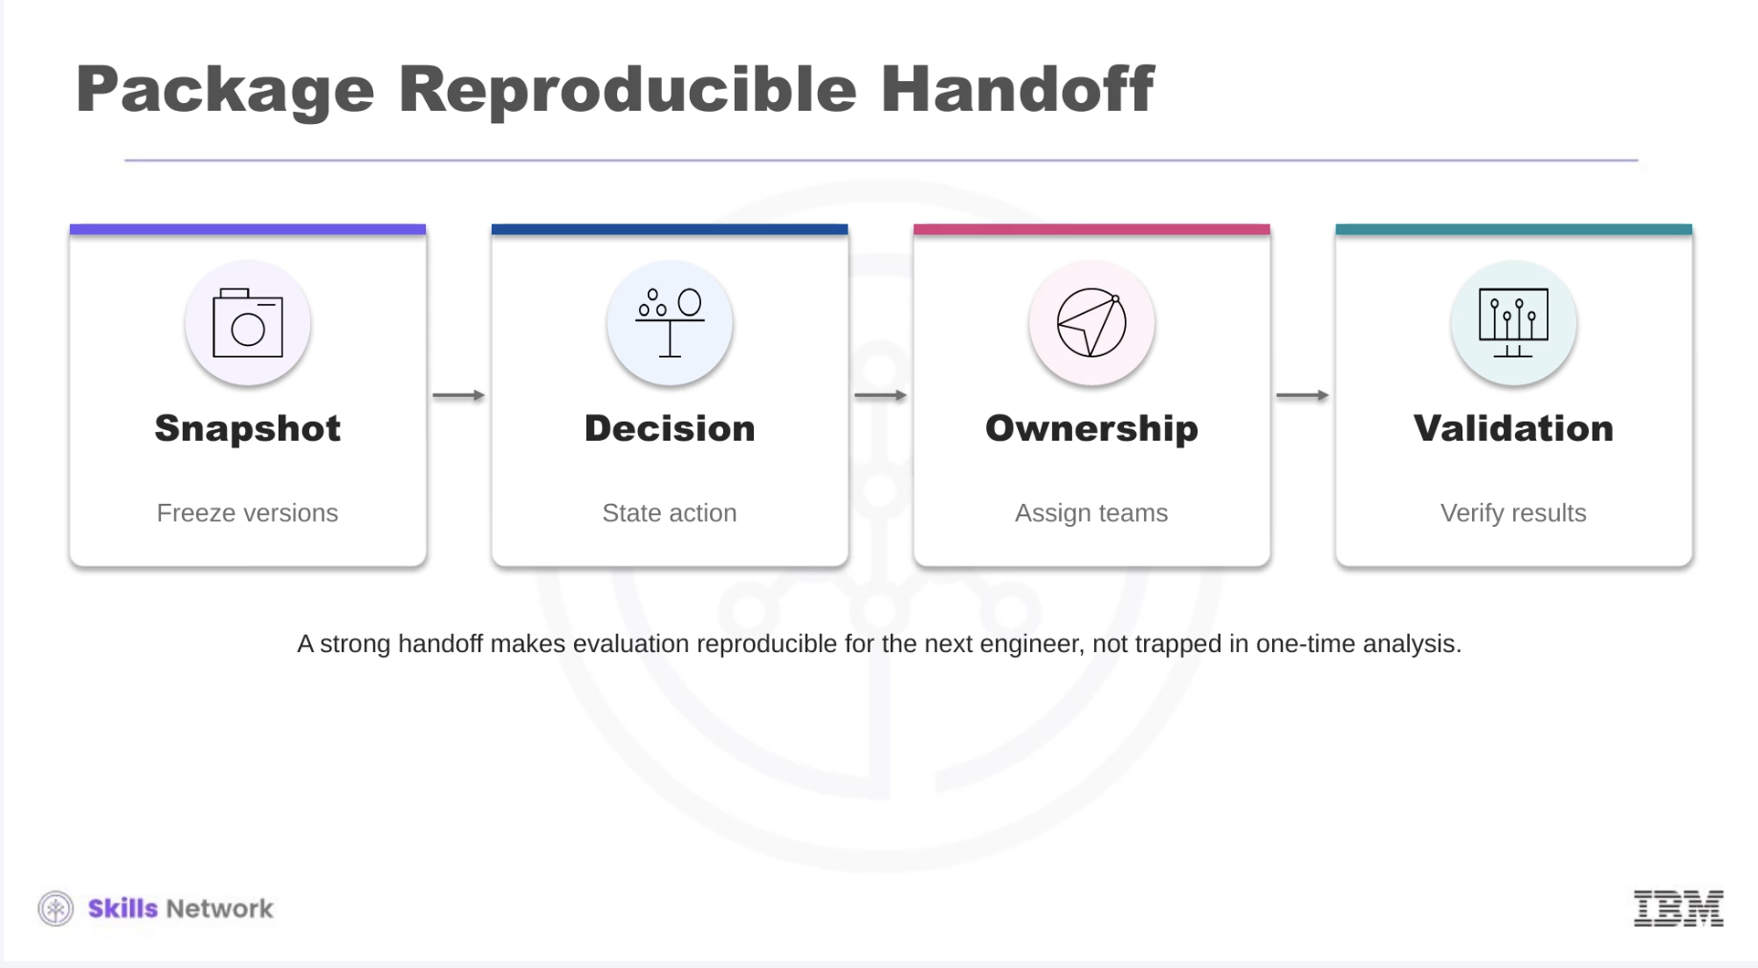
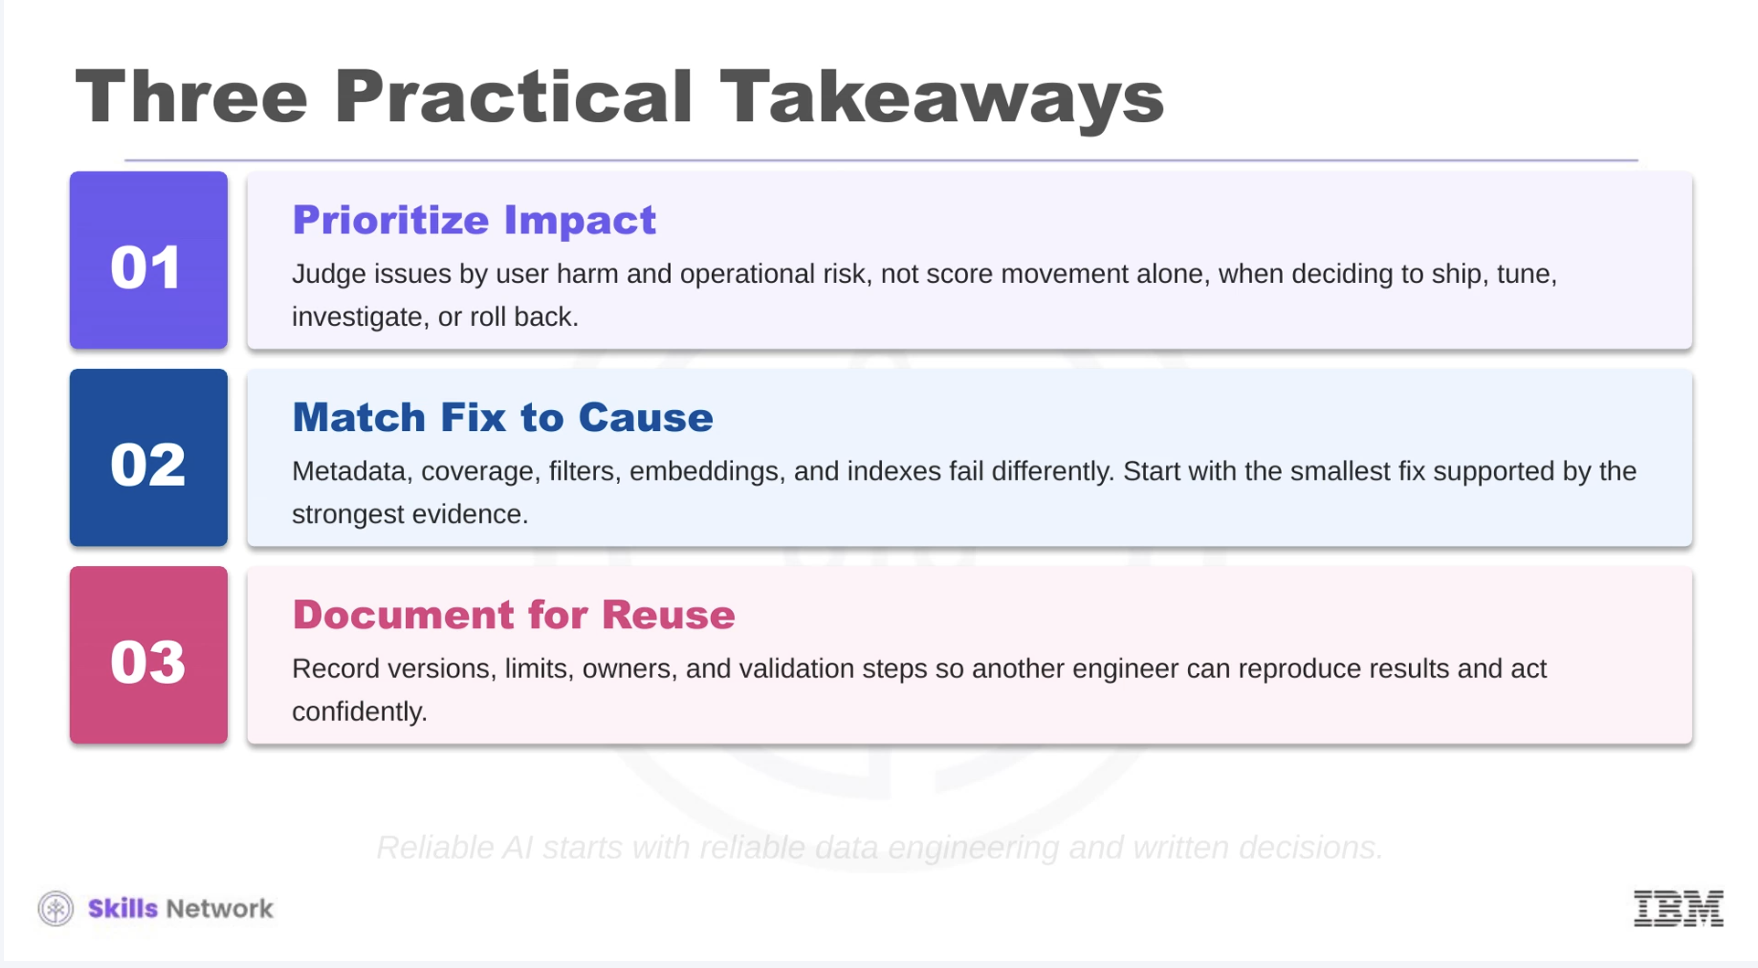


# Evaluation Limitations, Bias Risks & Improvement Backlogs

> 💡 **Core lesson:** A high retrieval score doesn't automatically mean a trustworthy retrieval system. I need to know **what the score actually covers**, whether the **labels are still valid**, whether **sensitive cases were tested**, and **what happens to the failures afterward**.

---

## 0. What This Chapter Answers

> "Okay, our retrieval metrics look good — but how do we know we can actually **trust** them?"

The main idea is that **evaluation itself can be wrong or incomplete**. A benchmark is only a **controlled approximation of production**, so I need to explicitly document its:

- scope
- corpus version
- labeling rules
- exclusions

---

## 1. Evaluation Has Boundaries

Suppose someone asks:

> "Is our retriever good enough to ship?"

I shouldn't immediately answer:

```
Recall@10 = 0.91
Therefore → YES
```

The real question is:

> **0.91 on what?**

I need to know:

- Which queries?
- Which users?
- Which corpus?
- Which index version?
- Which embedding model?
- What counted as relevant?
- What wasn't tested?

> 💡 The course calls this **the frame around the evidence**.

### Four things a proper evaluation report should state

| # | Item | Question it answers |
|---|---|---|
| 1 | **Evaluation scope** | What query types/users/workflows were tested? |
| 2 | **Corpus context** | Which corpus snapshot/index/embedding version? |
| 3 | **Judgment policy** | How did I decide that something was relevant? |
| 4 | **Known exclusions** | What wasn't tested? |

For example:

```
Excluded:
- newly published documents
- rare legal terminology
- sensitive cases
- long-tail languages
```

> ⚠️ Without this information, a reviewer may assume my benchmark represents **much more of production than it actually does**.

---

## 2. Bias Usually Starts BEFORE the Metric

This is an important concept.

> 💡 **Recall isn't biased. The dataset I calculate recall on can be biased.**

Imagine my golden dataset contains:

| Query type | Count |
|---|---|
| Easy FAQ queries | 900 |
| Policy queries | 50 |
| Multilingual queries | 20 |
| Permission-sensitive queries | 10 |

My overall Recall@10 could look **fantastic**. But I've **barely tested the difficult/important cases**.

So the problem wasn't:

```
Recall calculation ❌
```

It was:

```
Query selection ❌
```

> 📌 The course explicitly says bias enters through **which queries I include**, **how relevance is defined**, and **whose language patterns are represented**.

---

## 3. What Kinds of Bias Should I Look For?

| Bias type | What goes wrong |
|---|---|
| Query selection | Easy/common queries dominate |
| Labeling assumptions | Assuming exactly one correct document |
| Corpus representation | Test set doesn't look like production data |
| User diversity | Forgetting how different users actually ask |

### Query selection

Easy/common queries dominate:

```
"reset my password"
"what is PTO?"
```

while **difficult queries disappear**.

### Labeling assumptions

I assume there is **exactly one correct document**. But maybe:

```
Document A → valid
Document B → also valid
Document C → valid with different context
```

If I label only A as relevant, the benchmark can **unfairly punish** a retriever that finds B.

### Corpus representation

Maybe my test set is mostly:

```
clean Markdown
```

but production contains:

```
PDFs
tables
tickets
scanned docs
```

Then my benchmark **doesn't represent the real retrieval problem**.

### User diversity

I may forget:

- slang
- abbreviations
- multilingual queries
- code-mixed queries
- novice users
- expert terminology

> 📌 The course specifically recommends **explicit slices** for these types of variation.

---

## 4. A Benchmark Being BIG Doesn't Make It Representative

This is worth remembering.

Suppose I have:

```
1,000,000 queries
```

but they're all:

```
English
FAQ
common questions
public documents
```

That's a **huge** benchmark. But it's still a **bad representation of production** if production includes multilingual, permission-sensitive, expert, and long-tail queries.

So:

> 💡 **Representative ≠ large.** Representative means it contains the **right variation**.

The course states this directly: a benchmark becomes representative by covering the right kinds of variation, not merely by being large.

---

## 5. Stale Labels

This one is **VERY relevant to RAG**.

Imagine I created my benchmark in **January**. At that time:

```
HR handbook v1
```

was correct. Then in **July**:

```
HR handbook v2
```

replaced it. But my benchmark still says:

```
v1 = relevant ✅
```

Now my retriever gets **rewarded for returning outdated information**.

| | January | July |
|---|---|---|
| Correct handbook | v1 | v2 |
| Benchmark label says relevant | v1 ✅ | still v1 ❌ (stale) |

That's **stale labeling**.

> ⚠️ The evaluation itself is now **teaching me the wrong thing**.

The course describes exactly this problem: a page judged correct earlier can become misleading after the corpus/product changes.

---

## 6. Incomplete Judgments

This is slightly different.

Suppose my **old** retriever returned:

```
A
B
C
```

I labeled:

```
A = relevant
B = irrelevant
C = irrelevant
```

Later I build a **better** retriever:

```
D
A
E
```

But **nobody ever judged D**. Suppose:

```
D = actually relevant
```

My evaluation doesn't know that. So it might **incorrectly penalize** the new retriever.

| Document | Label in benchmark | Reality |
|---|---|---|
| A | relevant | relevant |
| B | irrelevant | irrelevant |
| C | irrelevant | irrelevant |
| **D** | **never judged** | **relevant** |
| E | never judged | — |

> 💡 This is why **unjudged ≠ irrelevant**. That's a very important distinction.

The course uses this exact scenario to show how incomplete judgments can make a **genuinely improved system look worse**.

### Stale labels vs incomplete judgments

| | Stale labels | Incomplete judgments |
|---|---|---|
| What's wrong | A label **was** correct but the world changed | A document was **never labeled** at all |
| Example | v1 handbook still marked relevant after v2 | New retriever's result D never judged |
| Effect | Rewards outdated results | Penalizes genuinely better results |

---

## 7. Don't Overreact to Tiny Metric Changes

Suppose:

```
Recall@10:
0.71 → 0.73
```

Is that an improvement? **Maybe.**

But maybe the difference came from:

- thin labels
- stale ground truth
- inconsistent judging
- small sample size

Therefore:

> 💡 **Small metric changes need context.**

The course specifically warns against treating tiny deltas as automatically meaningful.

---

## 8. Permission-Aware Retrieval Changes Everything

This is probably the **most important section for my security architecture**.

Normally I might ask:

> "Did retrieval find the relevant document?"

But in a secure system I need:

> "Did retrieval find a relevant document **that this user is actually allowed to see**?"

Those are **two different questions**.

Suppose:

```
User A → CEO
User B → normal employee
```

Both search:

```
"Executive compensation"
```

The same document could be:

| User | Relevant? | Authorized? | Result |
|---|---|---|---|
| A (CEO) | ✅ | ✅ | Correct |
| B (normal employee) | ✅ | ❌ Forbidden | **Failure** |

Returning that document to B is **not partially correct**. It's a **retrieval/security failure**.

> 📌 The course explicitly says that in permission-aware retrieval, **authorization is part of quality**.

---

## 9. Therefore My Evaluation Needs Authorization Context

My test cases should be tied to:

- Role
- Tenant
- Access tier
- Permissions
- Document policy

And distinguish:

| Outcome | Verdict |
|---|---|
| Relevant + Allowed | ✅ |
| Relevant + Forbidden | ❌ |
| Irrelevant | ❌ |

I can also use **masked/synthetic sensitive data** when real examples are risky, and **security/privacy/governance people** should participate in designing the evaluation.

> 📌 This fits exactly with the secure RAG architecture I've been designing.

---

## 10. Evaluation → Improvement Backlog

Now the chapter moves from:

> "We found problems."

to:

> "What the fuck are we actually going to do about them?"

Don't finish an evaluation with:

```
Recall = 0.82
MRR = 0.71
```

Finish with something **actionable**:

| Field | Example |
|---|---|
| **Problem** | Policy queries return outdated handbook pages. |
| **Evidence** | Low top-rank relevance in policy slice. |
| **Likely cause** | Stale embeddings + stale labels. |
| **Owner** | Search platform + content operations. |
| **Priority** | HIGH. |
| **Fix** | Re-embed affected corpus + refresh labels. |
| **Validation** | Rerun policy slice metrics.<br>Check unauthorized retrieval. |

> 💡 The course gives this exact structure: **issue → evidence → suspected cause → owner → priority → validation plan**.

That's the difference between:

| Evaluation | Engineering feedback loop |
|---|---|
| Reports numbers | Turns findings into owned, prioritized, validated fixes |

---

## 11. The Complete Mental Model

Put the entire chapter together:

```
             RETRIEVAL EVALUATION
                     │
                     ▼
             Measure metrics
                     │
                     ▼
          ┌─────────────────────┐
          │ "Can we trust this?"│
          └─────────────────────┘
                     │
        ┌────────────┼────────────┐
        ▼            ▼            ▼
      Scope         Bias       Labels
        │            │            │
     What was      What was    Are they
      tested?       missed?     current?
        │            │            │
        └────────────┼────────────┘
                     ▼
             Permission check
                     │
             Relevant + Allowed?
                     │
                     ▼
             Find weaknesses
                     │
                     ▼
          Improvement backlog
                     │
        ┌────────────┼────────────┐
        ▼            ▼            ▼
      Owner       Priority     Validation
        │            │            │
        └────────────┼────────────┘
                     ▼
               Re-evaluate
```

---

## What to Retain

| Priority | Topics |
|---|---|
| 🔴 **Must know** | - Evaluation is an approximation, not reality.<br>- Always document scope, corpus, labels, exclusions.<br>- Bias usually comes from the query set/labels, not the metric formula.<br>- Unjudged ≠ irrelevant.<br>- Labels can become stale.<br>- In secure RAG: relevance alone is insufficient; authorization matters.<br>- Every important finding should become an owned backlog item with a validation plan. |
| 🟡 **Understand** | - Different query slices<br>- Graded vs binary relevance<br>- Relabeling strategy<br>- Governance review |
| 🟢 **Don't memorize** | - The JSON examples<br>- Exact field names<br>- The example query strings |

> 💡 **The biggest takeaway:** A high retrieval score doesn't automatically mean a trustworthy retrieval system. I need to know what the score actually covers, whether the labels are still valid, whether sensitive cases were tested, and what happens to the failures afterward.